In [1]:
import numpy as np

# --- 1. Activation Functions ---
def sigmoid(x):
    """Sigmoid activation function: 1 / (1 + e^-x)"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of the sigmoid function (for backpropagation)"""
    return x * (1 - x)

# --- 2. Initial Data and Parameters ---

# Input data (x1, x2)
X = np.array([0.05, 0.10])

# Target value (t1, t2)
# We will use two outputs for a general example, focusing the error on t1.
# The problem statement implies a target value is given.
T = np.array([0.01, 0.99])

# Initial Weights (W AND W1 are given as per the request)

# Weights for the hidden layer (Input -> Hidden)
# w1, w2 for node 3, w3, w4 for node 4
W_ih = np.array([
    [0.15, 0.20],  # Weights going to hidden node 1 (h1)
    [0.25, 0.30]   # Weights going to hidden node 2 (h2)
])

# Weights for the output layer (Hidden -> Output)
# w5, w6 for node 5, w7, w8 for node 6
W_ho = np.array([
    [0.40, 0.45],  # Weights going to output node 1 (o1)
    [0.50, 0.55]   # Weights going to output node 2 (o2)
])

# Biases (b_h1, b_h2, b_o1, b_o2)
B_h = np.array([0.35, 0.35]) # Bias for hidden layer
B_o = np.array([0.60, 0.60]) # Bias for output layer

# Learning Rate
alpha = 0.5
print(f"--- Backpropagation Setup ---")
print(f"Learning Rate (alpha): {alpha}")
print(f"Initial Weights:\nInput->Hidden:\n{W_ih}\nHidden->Output:\n{W_ho}")
print("-" * 35)

# --- 3. Forward Pass ---

print("--- 1. Forward Pass ---")

# a) Calculate Net Input for Hidden Layer (h1, h2)
# Net_h = (X . W_ih) + B_h
Net_h = np.dot(X, W_ih) + B_h
Out_h = sigmoid(Net_h)

print(f"Net Input to Hidden Layer (Net_h): {Net_h}")
print(f"Output of Hidden Layer (Out_h): {Out_h}")

# b) Calculate Net Input for Output Layer (o1, o2)
# Net_o = (Out_h . W_ho) + B_o
Net_o = np.dot(Out_h, W_ho) + B_o
Out_o = sigmoid(Net_o)

print(f"Net Input to Output Layer (Net_o): {Net_o}")
print(f"Final Output (Out_o): {Out_o}")
print("-" * 35)

# --- 4. Total Error Calculation (Mean Squared Error) ---
# Cost = 0.5 * sum((Target - Output)^2)
Error_total = 0.5 * np.sum((T - Out_o) ** 2)
print(f"Total Initial Error (E_total): {Error_total:.6f}")
print("-" * 35)

# --- 5. Backward Pass (Updating Output Layer Weights) ---

print("--- 2. Backward Pass: Output Layer ---")
# [Image of Backpropagation Algorithm Flow]

# a) Calculate Output Error Term (Delta_o)
# The error term (delta) for the output layer is:
# (Target - Output) * derivative_of_activation(Net_o)

# 1. Error for each output node (Target - Output)
E_o = T - Out_o

# 2. Local gradient (dE/dOut * dOut/dNet)
# dE/dOut_o is -(T - Out_o)
# dOut_o/dNet_o is Out_o * (1 - Out_o)
# So, Delta_o = -(T - Out_o) * Out_o * (1 - Out_o)
# We use E_o * dOut/dNet_o
Delta_o = E_o * sigmoid_derivative(Out_o)

print(f"Output Layer Error (E_o): {E_o}")
print(f"Output Layer Delta (Delta_o): {Delta_o}")

# b) Calculate Weight Changes (Delta_W_ho)
# Delta_W_ho = alpha * Delta_o * Out_h
Delta_W_ho = alpha * np.outer(Out_h, Delta_o)

print(f"Weight Change Matrix (Delta_W_ho):\n{Delta_W_ho}")

# c) Update Output Layer Weights
W_ho_new = W_ho + Delta_W_ho
print(f"NEW Hidden -> Output Weights (W_ho):\n{W_ho_new}")
print("-" * 35)


# --- 6. Backward Pass (Updating Hidden Layer Weights) ---

print("--- 3. Backward Pass: Hidden Layer ---")

# a) Calculate Hidden Error Term (Delta_h)
# Hidden error is the sum of output errors weighted by the connecting weights (W_ho)
# Error_h = sum(Delta_o * W_ho_transpose)
Error_h = np.dot(Delta_o, W_ho.T)

# 2. Local gradient for hidden layer (Error_h * derivative_of_activation(Net_h))
# dOut_h/dNet_h is Out_h * (1 - Out_h)
Delta_h = Error_h * sigmoid_derivative(Out_h)

print(f"Hidden Layer Error (E_h): {Error_h}")
print(f"Hidden Layer Delta (Delta_h): {Delta_h}")

# b) Calculate Weight Changes (Delta_W_ih)
# Delta_W_ih = alpha * Delta_h * X
# np.outer(X, Delta_h) is used because X is 1x2 and Delta_h is 1x2,
# resulting in a 2x2 matrix of changes.
Delta_W_ih = alpha * np.outer(X, Delta_h)

print(f"Weight Change Matrix (Delta_W_ih):\n{Delta_W_ih}")

# c) Update Hidden Layer Weights
W_ih_new = W_ih + Delta_W_ih
print(f"NEW Input -> Hidden Weights (W_ih):\n{W_ih_new}")
print("-" * 35)

print("\n--- Summary of New Weights After One Pass ---")
print("Input -> Hidden Weights (W_ih):")
print(W_ih_new)
print("\nHidden -> Output Weights (W_ho):")
print(W_ho_new)

# --- Note on Bias Update ---
# Bias updates follow the same gradient rule as weights, but without the input term.
# Delta_B_o = alpha * Delta_o
# Delta_B_h = alpha * Delta_h
# B_o_new = B_o + alpha * Delta_o
# B_h_new = B_h + alpha * Delta_h
# This example focuses on weight updates for simplicity.

--- Backpropagation Setup ---
Learning Rate (alpha): 0.5
Initial Weights:
Input->Hidden:
[[0.15 0.2 ]
 [0.25 0.3 ]]
Hidden->Output:
[[0.4  0.45]
 [0.5  0.55]]
-----------------------------------
--- 1. Forward Pass ---
Net Input to Hidden Layer (Net_h): [0.3825 0.39  ]
Output of Hidden Layer (Out_h): [0.59447593 0.5962827 ]
Net Input to Output Layer (Net_o): [1.13593172 1.19546965]
Final Output (Out_o): [0.75693192 0.76771788]
-----------------------------------
Total Initial Error (E_total): 0.303658
-----------------------------------
--- 2. Backward Pass: Output Layer ---
Output Layer Error (E_o): [-0.74693192  0.22228212]
Output Layer Delta (Delta_o): [-0.13742501  0.03963893]
Weight Change Matrix (Delta_W_ho):
[[-0.04084793  0.0117822 ]
 [-0.04097208  0.01181801]]
NEW Hidden -> Output Weights (W_ho):
[[0.35915207 0.4617822 ]
 [0.45902792 0.56181801]]
-----------------------------------
--- 3. Backward Pass: Hidden Layer ---
Hidden Layer Error (E_h): [-0.03713248 -0.04691109]
Hidde

In [ ]:
a = ['a','b','c']
for item in a:
    print(item)

a
b
c


In [ ]:
a = ['a','b','c']
b = ['x','y','z']

for item1, item2 in zip(a,b):
    print(item1,item2)

a x
b y
c z


Gradient Descent Algorithm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# generate data
X = np.linspace(-2, 10, 10)
y = 2 + X * 1.25

In [ ]:
y


array([-0.5       ,  1.16666667,  2.83333333,  4.5       ,  6.16666667,
        7.83333333,  9.5       , 11.16666667, 12.83333333, 14.5       ])

Text(0, 0.5, '$f(x) = 2 + 1.25 x $')

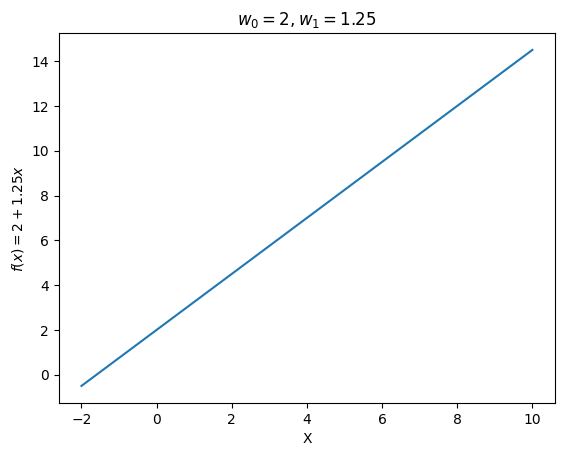

In [ ]:
plt.plot(X, y)
plt.title(r'$w_0 = 2, w_1=1.25$')
plt.xlabel(r'X')
plt.ylabel(r'$f(x) = 2 + 1.25 x $')

In [ ]:
# hypothesis
def h(x, w0, w1):
    return w0 + w1 * x

In [ ]:
# Stochastic gradient descent

# initialize the parameters to zero
w0 = 0.0
w1 = 0.0


# the learning rate. Experiement by changing alpha to see its impact on training.
alpha = 0.05

d = []  # an array to store the states for generating plot
delta = 0  # a variable to store the error.

# change here to reduce or increase the
# number of iterations (epochs)
for i in range(1, 50):

    print('Iteration: {} \t w0:{:0f} \t w1:{:0f} \t J:{:0f}'.format(
        i, w0, w1, delta**2))
    print('='*70)

    # zip is used to iterate over two iterable variables simultaneously
    for x_i, y_i in zip(X, y):

        # calculate the error i.e. diffrecne between estimated and acutal values
        delta = h(x_i, w0, w1) - y_i
        w0 = w0 - alpha * delta       # update w_0
        w1 = w1 - alpha * delta * x_i  # updtae w_1
        # print('='*70)
    d.append(delta)

Iteration: 1 	 w0:0.000000 	 w1:0.000000 	 J:0.000000
Iteration: 2 	 w0:0.765014 	 w1:2.694747 	 J:10.642866
Iteration: 3 	 w0:0.803627 	 w1:1.050436 	 J:0.621181
Iteration: 4 	 w0:1.153974 	 w1:1.844254 	 J:1.583566
Iteration: 5 	 w0:1.257816 	 w1:1.308058 	 J:0.001592
Iteration: 6 	 w0:1.439570 	 w1:1.529086 	 J:0.303296
Iteration: 7 	 w0:1.530777 	 w1:1.344882 	 J:0.014023
Iteration: 8 	 w0:1.634300 	 w1:1.397792 	 J:0.075417
Iteration: 9 	 w0:1.700533 	 w1:1.328817 	 J:0.014561
Iteration: 10 	 w0:1.763029 	 w1:1.335330 	 J:0.023159
Iteration: 11 	 w0:1.807990 	 w1:1.306213 	 J:0.008352
Iteration: 12 	 w0:1.846950 	 w1:1.301914 	 J:0.008171
Iteration: 13 	 w0:1.876614 	 w1:1.287880 	 J:0.003977
Iteration: 14 	 w0:1.901306 	 w1:1.282495 	 J:0.003121
Iteration: 15 	 w0:1.920627 	 w1:1.274911 	 J:0.001756
Iteration: 16 	 w0:1.936405 	 w1:1.270636 	 J:0.001243
Iteration: 17 	 w0:1.948914 	 w1:1.266201 	 J:0.000750
Iteration: 18 	 w0:1.959036 	 w1:1.263199 	 J:0.000505
Iteration: 19 	 w0

Text(0, 0.5, 'Error: $h(x)-y$')

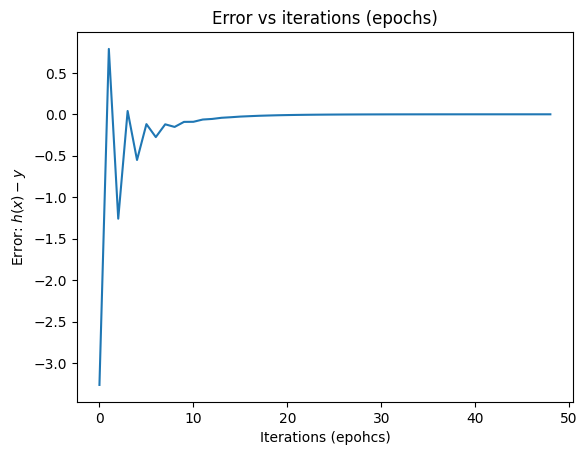

In [ ]:
plt.plot(d)
plt.title("Error vs iterations (epochs)")
plt.xlabel("Iterations (epohcs)")
plt.ylabel(r"Error: $h(x)-y$")


**Batch gradient descent**

In [ ]:
w0 = 0
w1 = 0
alpha = 0.05

for i in range(1, 150):
    print('Batch Iteration: {} \t w0:{:0f} \t w1:{:0f}'.format(i, w0, w1))
    delta = np.array([])
    for x_i, y_i in zip(X, y):
        ypred = h(x_i, w0, w1)
        delta = np.append(delta, ypred-y_i)
        # print(delta)
    w0 = w0 - alpha * sum(delta)/len(delta)
    w1 = w1 - alpha * sum(delta * X)/len(delta)

Batch Iteration: 1 	 w0:0.000000 	 w1:0.000000
Batch Iteration: 2 	 w0:0.350000 	 w1:2.316667
Batch Iteration: 3 	 w0:0.219167 	 w1:1.011111
Batch Iteration: 4 	 w0:0.355986 	 w1:1.733574
Batch Iteration: 5 	 w0:0.341472 	 w1:1.320897
Batch Iteration: 6 	 w0:0.410219 	 w1:1.543894
Batch Iteration: 7 	 w0:0.430929 	 w1:1.411213
Batch Iteration: 8 	 w0:0.477140 	 w1:1.477834
Batch Iteration: 9 	 w0:0.507716 	 w1:1.433060
Batch Iteration: 10 	 w0:0.545719 	 w1:1.450824
Batch Iteration: 11 	 w0:0.578268 	 w1:1.433750
Batch Iteration: 12 	 w0:0.612604 	 w1:1.436347
Batch Iteration: 13 	 w0:0.644705 	 w1:1.428094
Batch Iteration: 14 	 w0:0.676851 	 w1:1.426075
Batch Iteration: 15 	 w0:0.707793 	 w1:1.420723
Batch Iteration: 16 	 w0:0.738259 	 w1:1.417389
Batch Iteration: 17 	 w0:0.767868 	 w1:1.413074
Batch Iteration: 18 	 w0:0.796860 	 w1:1.409454
Batch Iteration: 19 	 w0:0.825126 	 w1:1.405586
Batch Iteration: 20 	 w0:0.852753 	 w1:1.401995
Batch Iteration: 21 	 w0:0.879716 	 w1:1.398385
B

In [ ]:
import numpy as np

# --- 1. Synthetic Data Generation ---
# A simple linear relationship: y = 2 + 3*x + noise
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 data points for one feature
y = 4 + 3 * X + np.random.randn(100, 1)

# Add a column of ones to X for the intercept term (theta_0)
X_b = np.c_[np.ones((100, 1)), X] # X_b is the "biased" feature matrix

# --- 2. Gradient Descent Implementations ---

def batch_gradient_descent(X_b, y, learning_rate, n_iterations):
    """
    Performs Batch Gradient Descent (BGD).

    X_b: Feature matrix with the intercept column
    y: Target values
    learning_rate: The alpha value (e.g., 0.05)
    n_iterations: Number of full passes over the dataset
    """
    m = len(y) # Number of training examples
    theta = np.zeros((2, 1)) # Initialize theta = [theta_0, theta_1]

    # Stores the theta values at required iteration counts
    theta_history = {}

    # Store initial values for iteration 0
    theta_history[0] = theta.copy()

    for iteration in range(1, n_iterations + 1):
        # Calculate the gradient over the ENTIRE dataset
        gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y)

        # Update theta
        theta = theta - learning_rate * gradients

        # Check if the current iteration is one we need to record
        if iteration in [10, 25, 50]:
            theta_history[iteration] = theta.copy()

    return theta_history

def stochastic_gradient_descent(X_b, y, learning_rate, n_epochs):
    """
    Performs Stochastic Gradient Descent (SGD).

    X_b: Feature matrix with the intercept column
    y: Target values
    learning_rate: The alpha value (e.g., 0.05)
    n_epochs: Number of times to pass through the entire dataset
    """
    m = len(y) # Number of training examples
    theta = np.zeros((2, 1)) # Initialize theta = [theta_0, theta_1]

    theta_history = {}
    theta_history[0] = theta.copy()

    # We use 'epoch' here to represent a pass over the entire dataset.
    # The prompt asks for results after 10, 25, 50 ITERATIONS.
    # For fair comparison, we'll treat 1 ITERATION = 1 EPOCH (a full pass).

    for epoch in range(1, n_epochs + 1):
        # We need to shuffle the data before each epoch for true SGD
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            # Pick one random instance
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            # Calculate the gradient using ONLY this one instance
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)

            # Update theta
            theta = theta - learning_rate * gradients

        # Check if the current epoch is one we need to record
        if epoch in [10, 25, 50]:
            theta_history[epoch] = theta.copy()

    return theta_history

# --- 3. Experiment and Reporting ---

def run_experiment(alpha, X_b, y):
    """Runs BGD and SGD for a given alpha and prints the results."""

    # BGD results
    bgd_history = batch_gradient_descent(X_b, y, alpha, n_iterations=50)

    # SGD results (treating 1 iteration = 1 epoch/full data pass)
    sgd_history = stochastic_gradient_descent(X_b, y, alpha, n_epochs=50)

    print(f"\n## 🧪 Results for Learning Rate ($\\alpha$) = {alpha}\n")

    # --- Table 1: Theta_0 ---
    print("### Table 1: Parameter $\\theta_0$ (Intercept) Values")
    print("| Iterations | $\\theta_0$ (Batch GD) | $\\theta_0$ (Stochastic GD) |")
    print("| :--------: | :--------------------: | :--------------------------:|")
    for i in [10, 25, 50]:
        theta0_bgd = bgd_history[i][0, 0]
        theta0_sgd = sgd_history[i][0, 0]
        print(f"| **{i}** | {theta0_bgd:^20.6f} | {theta0_sgd:^25.6f} |")

    print("\n---")

    # --- Table 2: Theta_1 ---
    print("### Table 2: Parameter $\\theta_1$ (Slope) Values")
    print("| Iterations | $\\theta_1$ (Batch GD) | $\\theta_1$ (Stochastic GD) |")
    print("| :--------: | :--------------------: | :--------------------------:|")
    for i in [10, 25, 50]:
        theta1_bgd = bgd_history[i][1, 0]
        theta1_sgd = sgd_history[i][1, 0]
        print(f"| **{i}** | {theta1_bgd:^20.6f} | {theta1_sgd:^25.6f} |")

    print("\n" + "="*70 + "\n")


# --- 4. Execute Experiment for all Alpha Values ---

# The required alpha values
alpha_values = [0.05, 0.1, 0.5]

for alpha in alpha_values:
    run_experiment(alpha, X_b, y)


## 🧪 Results for Learning Rate ($\alpha$) = 0.05

### Table 1: Parameter $\theta_0$ (Intercept) Values
| Iterations | $\theta_0$ (Batch GD) | $\theta_0$ (Stochastic GD) |
| :--------: | :--------------------: | :--------------------------:|
| **10** |       3.058583       |         4.257517          |
| **25** |       3.557105       |         4.209457          |
| **50** |       3.792613       |         4.119927          |

---
### Table 2: Parameter $\theta_1$ (Slope) Values
| Iterations | $\theta_1$ (Batch GD) | $\theta_1$ (Stochastic GD) |
| :--------: | :--------------------: | :--------------------------:|
| **10** |       3.148830       |         2.780374          |
| **25** |       3.331085       |         2.716726          |
| **50** |       3.143081       |         2.650021          |



## 🧪 Results for Learning Rate ($\alpha$) = 0.1

### Table 1: Parameter $\theta_0$ (Intercept) Values
| Iterations | $\theta_0$ (Batch GD) | $\theta_0$ (Stochastic GD) |
| :--------: | :-----